## Plot function for "Isolate Label Skew Effects"

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

BETA_L_VALUES = [0.1,0.25,0.5,0.75,1.0,1.5,2.0,10.0]
BETA_Q_VALUES = [0.1,0.25,0.5,0.75,1.0,1.5,2.0,10.0]


def plot_macro_f1_vs_beta_L(csv_path, save_dir=None):

    df = pd.read_csv(csv_path)

    f1_cols = [
        "F1_global_AlveolarOsteitis",
        "F1_global_SecondaryInfection",
        "F1_global_NerveDysesthesia",
        "F1_global_Bleeding",
    ]

    # macro F1
    df["macro_f1"] = df[f1_cols].mean(axis=1)

    paradigms = df["paradigm"].unique()

    for beta_q in BETA_Q_VALUES:

        sub_df = df[df["beta_Q"] == beta_q].copy()

        if sub_df.empty:
            print(f"No data for beta_Q={beta_q}")
            continue

        plt.figure(figsize=(8,5))

        for paradigm in paradigms:

            p_df = sub_df[sub_df["paradigm"] == paradigm]

            # ensure correct order
            p_df = p_df.sort_values("beta_L")

            plt.plot(
                p_df["beta_L"],
                p_df["macro_f1"],
                marker="o",
                label=paradigm
            )

        plt.xlabel(r"Label skew $\beta_L$")
        plt.ylabel("Macro F1")
        plt.title(f"Macro F1 vs $\\beta_L$  (β_Q={beta_q})")

        plt.xticks(BETA_L_VALUES)

        plt.legend(title="Paradigm")
        plt.grid(True)
        plt.tight_layout()

        if save_dir is not None:
            path = f"{save_dir}/macroF1_betaQ_{beta_q}.png"
            plt.savefig(path, dpi=300, bbox_inches="tight")

        plt.show()

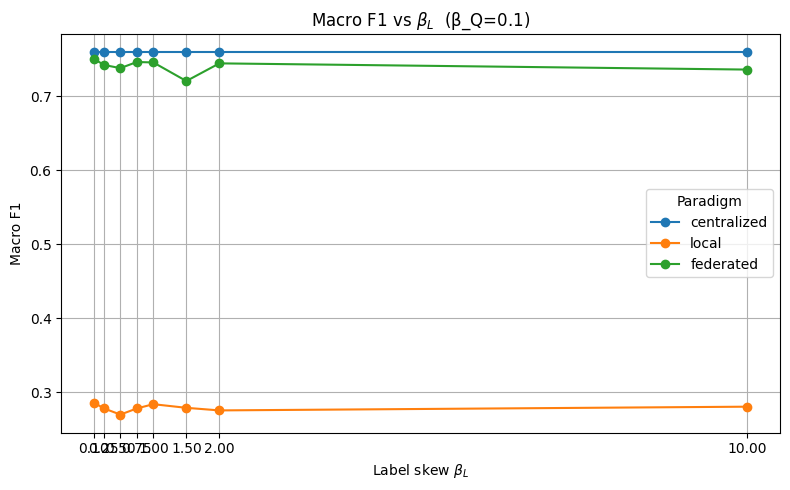

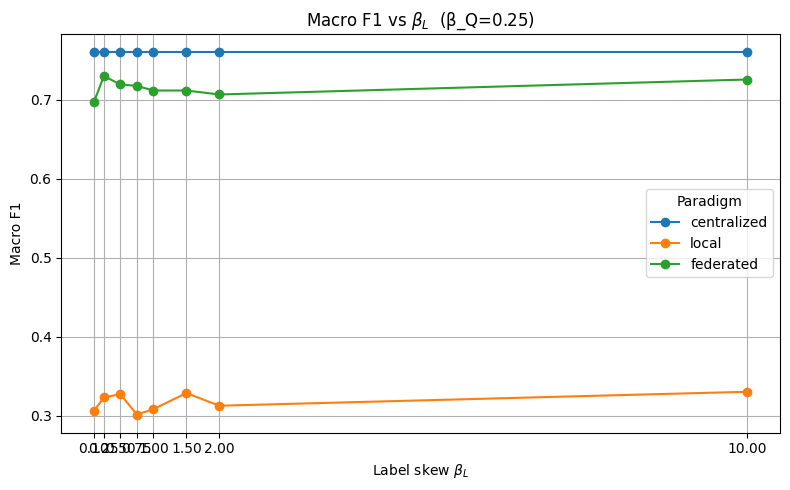

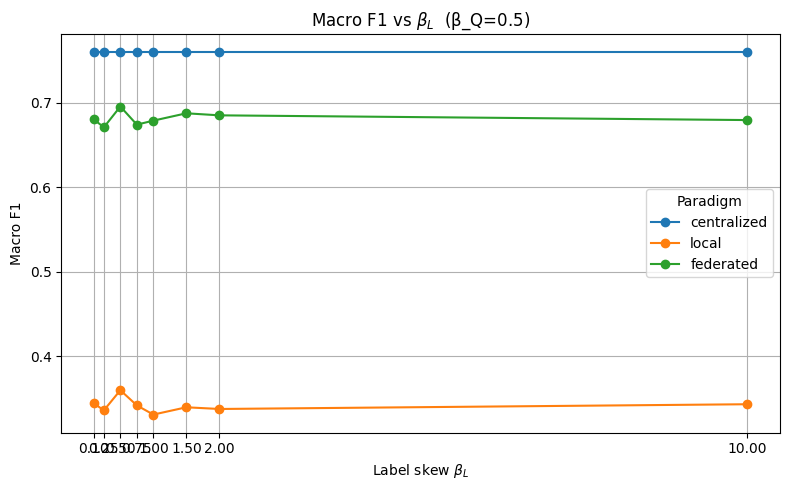

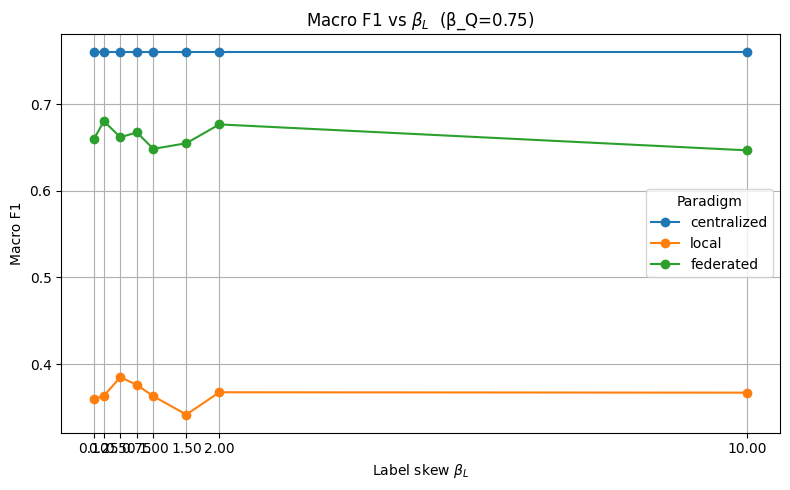

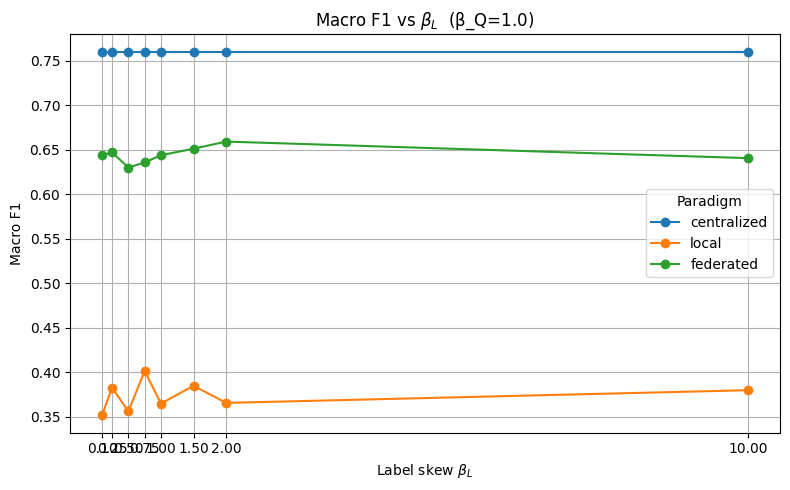

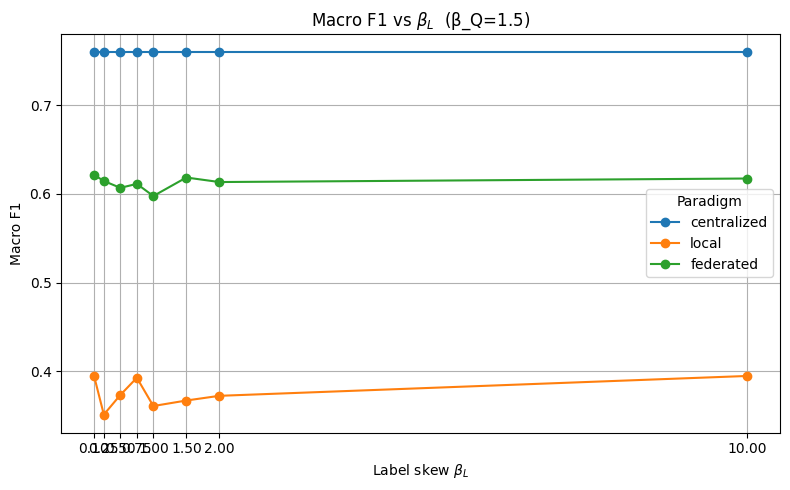

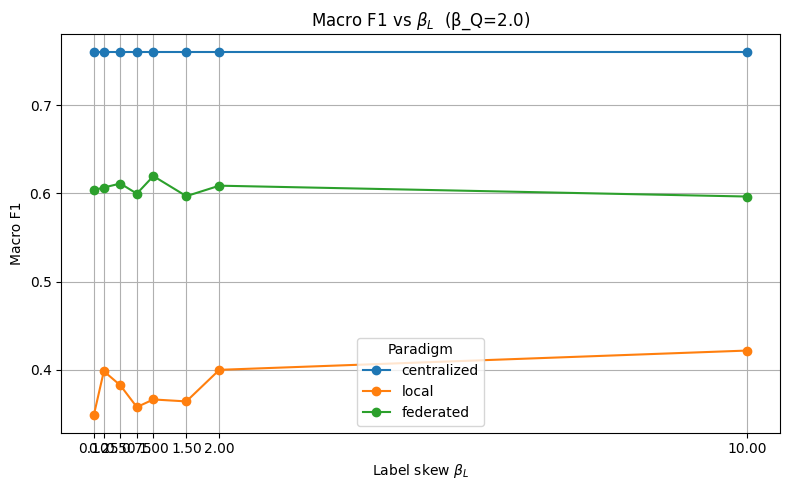

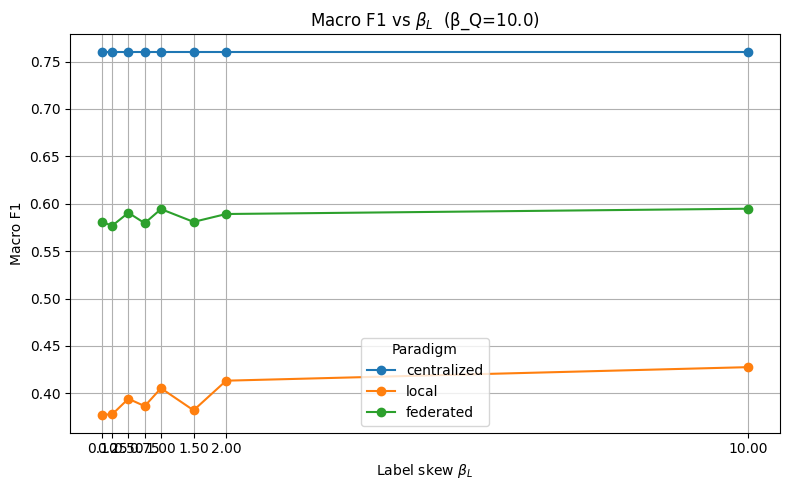

In [14]:
csv_path = r"C:\Users\Oskar\Desktop\Dataproject\federated-dental-risk-vol2\src\fdrp\analysis\Results\sweep_beta_summary_1.csv"
plot_macro_f1_vs_beta_L(csv_path)

Jeg tror grunden til at local klarer sig så dårligt er, at jeg har implementeret local metrics som et gennemsnit og ikke et vægtet gennemsnit. Det skal vi lige snakke med ruben om.

## Plot Function for Quantity skew

In [16]:
import pandas as pd
import matplotlib.pyplot as plt


BETA_L_VALUES = [0.1,0.25,0.5,0.75,1.0,1.5,2.0,10.0]
BETA_Q_VALUES = [0.1,0.25,0.5,0.75,1.0,1.5,2.0,10.0]


def plot_quantity_skew_all_beta_L(csv_path, save_dir=None):

    df = pd.read_csv(csv_path)

    f1_cols = [
        "F1_global_AlveolarOsteitis",
        "F1_global_SecondaryInfection",
        "F1_global_NerveDysesthesia",
        "F1_global_Bleeding",
    ]

    # compute macro F1
    df["macro_f1"] = df[f1_cols].mean(axis=1)

    paradigms = df["paradigm"].unique()

    for beta_l in BETA_L_VALUES:

        sub_df = df[df["beta_L"] == beta_l].copy()

        if sub_df.empty:
            print(f"No data for beta_L={beta_l}")
            continue

        plt.figure(figsize=(8,5))

        for paradigm in paradigms:

            p_df = sub_df[sub_df["paradigm"] == paradigm]

            p_df = p_df.sort_values("beta_Q")

            plt.plot(
                p_df["beta_Q"],
                p_df["macro_f1"],
                marker="o",
                label=paradigm
            )

        plt.xlabel(r"Quantity skew $\beta_Q$")
        plt.ylabel("Macro F1")
        plt.title(f"Macro F1 vs $\\beta_Q$  (β_L={beta_l})")

        plt.xticks(BETA_Q_VALUES)

        plt.legend(title="Paradigm")
        plt.grid(True)
        plt.tight_layout()

        if save_dir is not None:
            path = f"{save_dir}/macroF1_betaL_{beta_l}.png"
            plt.savefig(path, dpi=300, bbox_inches="tight")

        plt.show()

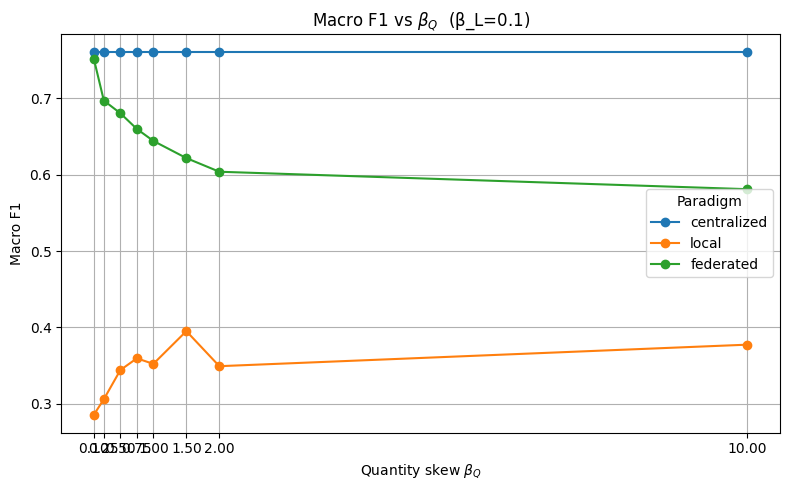

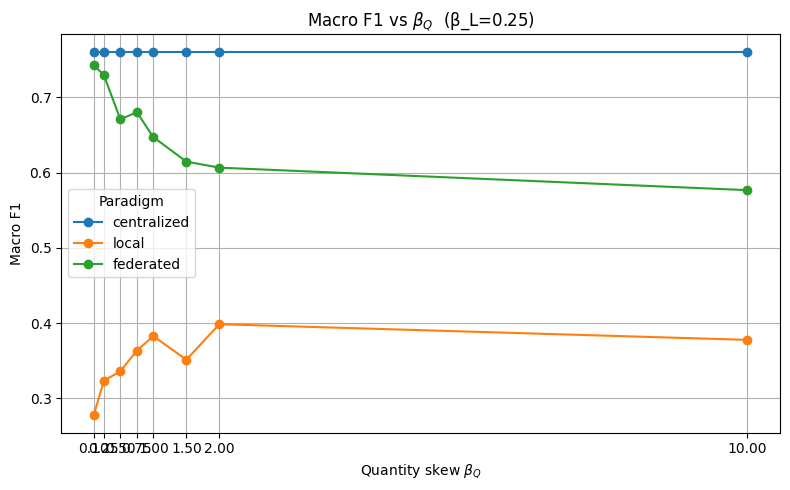

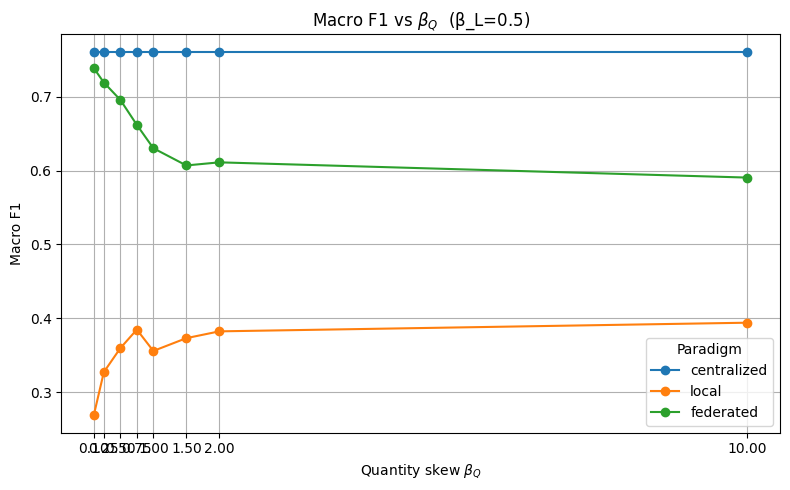

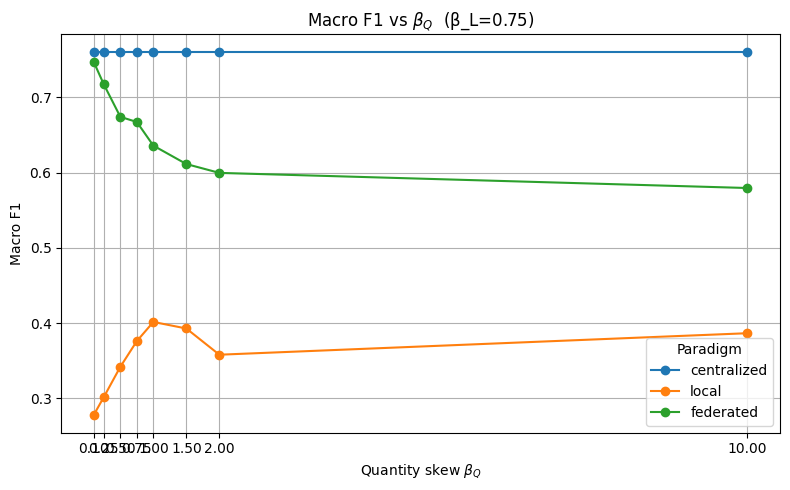

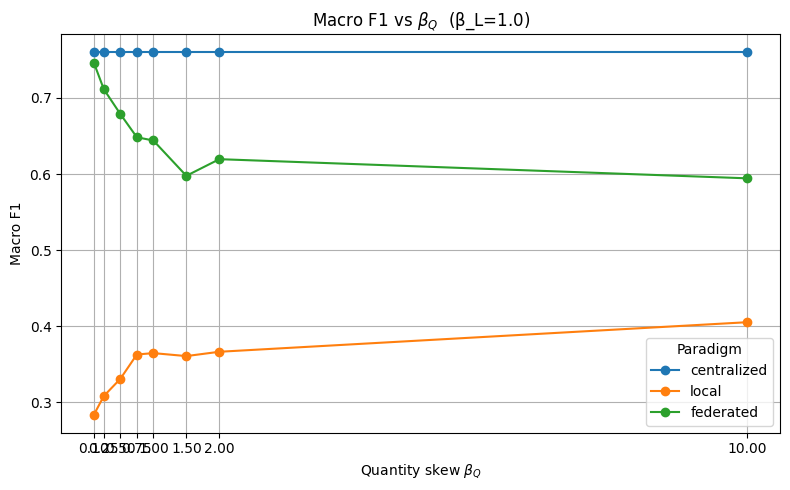

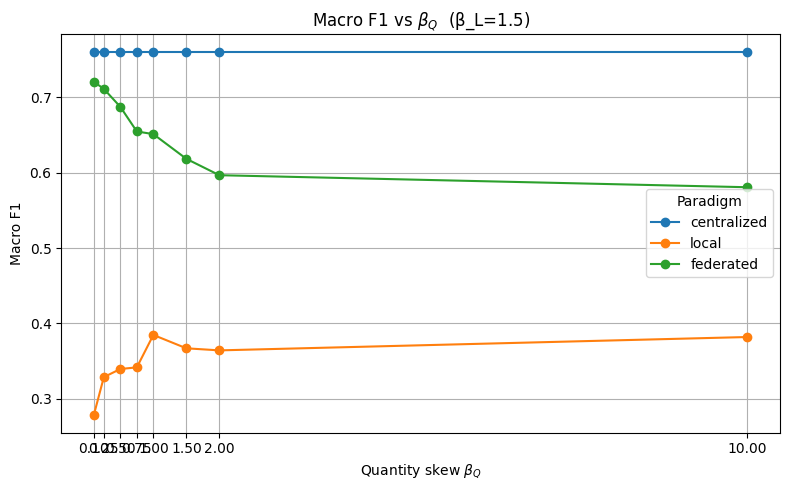

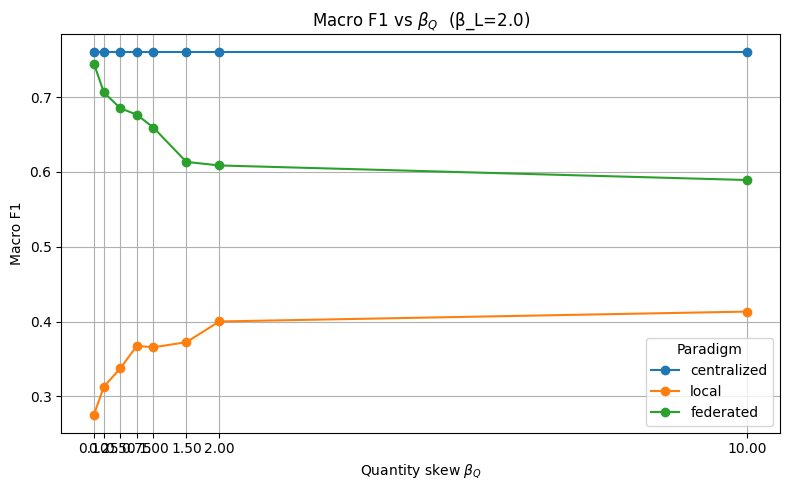

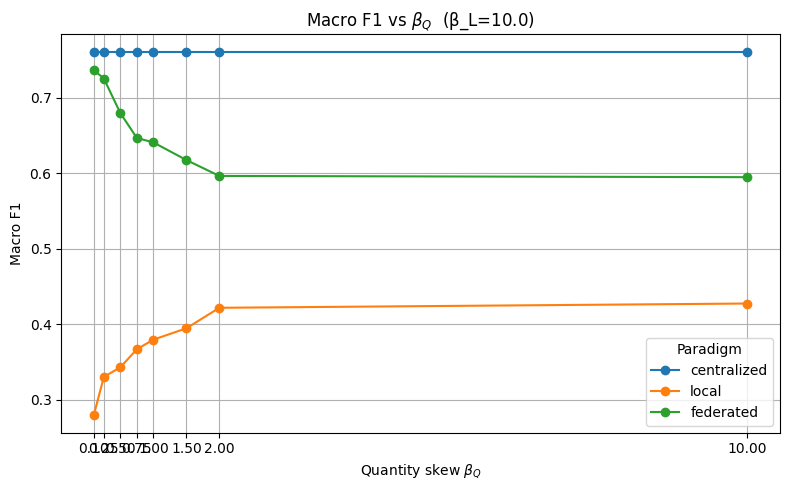

In [17]:
plot_quantity_skew_all_beta_L(csv_path)

### Data inspection

In [18]:
import pandas as pd

df = pd.read_csv(csv_path)

df

,paradigm,beta_L,beta_Q,seed,f1_global_macro,f1_per_client_macro,mse_macro,ece_macro,MSE_AlveolarOsteitis,ECE_AlveolarOsteitis,...,fleiss_kappa_global_macro,partition_beta_L,partition_beta_Q,partition_label,partition_min_size,partition_mean_kl_divergence,partition_std_kl_divergence,partition_min_client_size,partition_max_client_size,partition_std_client_size
0,centralized,0.1,0.10,42,0.760391,0.643214,0.000293,0.002090,0.000668,0.003546,...,1.000000,0.1,0.10,Risk_Category_Composite,100,1.220366,0.539008,100,37376,11210.257330
1,local,0.1,0.10,42,0.286070,0.376621,0.110300,0.272403,0.110772,0.274764,...,0.063473,0.1,0.10,Risk_Category_Composite,100,1.220366,0.539008,100,37376,11210.257330
2,federated,0.1,0.10,42,0.750794,0.635268,0.000392,0.002412,0.000898,0.002205,...,1.000000,0.1,0.10,Risk_Category_Composite,100,1.220366,0.539008,100,37376,11210.257330
3,centralized,0.1,0.25,42,0.760391,0.644076,0.000293,0.002090,0.000668,0.003546,...,1.000000,0.1,0.25,Risk_Category_Composite,100,1.116826,0.511357,100,25628,8071.560246
4,local,0.1,0.25,42,0.306165,0.377551,0.065150,0.173291,0.045253,0.144301,...,0.067657,0.1,0.25,Risk_Category_Composite,100,1.116826,0.511357,100,25628,8071.560246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,local,10.0,2.00,42,0.421917,0.471103,0.001621,0.009814,0.002845,0.014667,...,0.253961,10.0,2.00,Risk_Category_Composite,100,0.242727,0.427672,629,11627,2860.302222
188,federated,10.0,2.00,42,0.596379,0.649718,0.000568,0.005499,0.001194,0.006518,...,1.000000,10.0,2.00,Risk_Category_Composite,100,0.242727,0.427672,629,11627,2860.302222
189,centralized,10.0,10.00,42,0.760391,0.744003,0.000293,0.002090,0.000668,0.003546,...,1.000000,10.0,10.00,Risk_Category_Composite,100,0.053523,0.066405,2510,7699,1318.754109
190,local,10.0,10.00,42,0.427569,0.491894,0.001170,0.005334,0.002169,0.009194,...,0.338952,10.0,10.00,Risk_Category_Composite,100,0.053523,0.066405,2510,7699,1318.754109


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def plot_mu_sweep(csv_path, metric="f1_global_macro", save_path=None):

    df = pd.read_csv(csv_path)

    plt.figure(figsize=(7,5))

    df_fed = df[df["paradigm"] == "federated"].copy()
    df_fed = df_fed.sort_values("fedprox_mu")

    # split μ=0 and μ>0
    df_pos = df_fed[df_fed["fedprox_mu"] > 0]
    df_zero = df_fed[df_fed["fedprox_mu"] == 0]

    # plot FedProx curve
    plt.plot(
        df_pos["fedprox_mu"],
        df_pos[metric],
        marker="o",
        linewidth=2,
        label="FedProx"
    )

    # plot FedAvg separately
    if not df_zero.empty:
        fedavg_val = df_zero.iloc[0][metric]
        mu_fake = df_pos["fedprox_mu"].min() / 5

        plt.scatter(
            mu_fake,
            fedavg_val,
            s=90,
            label="FedAvg (μ=0)"
        )

    # baselines
    df_cent = df[df["paradigm"] == "centralized"]
    if not df_cent.empty:
        plt.axhline(df_cent.iloc[0][metric], linestyle="--", label="Centralized")

    df_local = df[df["paradigm"] == "local"]
    if not df_local.empty:
        plt.axhline(df_local.iloc[0][metric], linestyle=":", label="Local")

    plt.xscale("log")

    plt.xlabel("FedProx μ (log scale)")
    plt.ylabel(metric)
    plt.title(f"{metric} vs FedProx μ")

    plt.grid(True)
    plt.legend()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

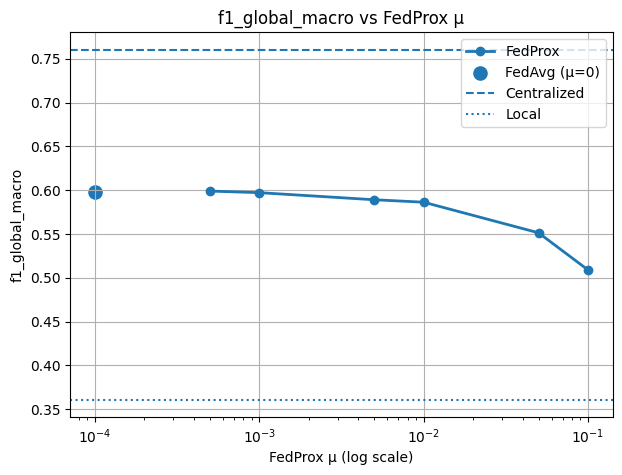

In [28]:
csv_path_mu_1 = r"C:\Users\Oskar\Desktop\fedprox_mu_sweep_summary_1_15.csv"
csv_path_mu_2 = r"C:\Users\Oskar\Desktop\fedprox_mu_sweep_summary_05_15.csv"
plot_mu_sweep(
    csv_path=csv_path_mu_1,
    metric="f1_global_macro"
)

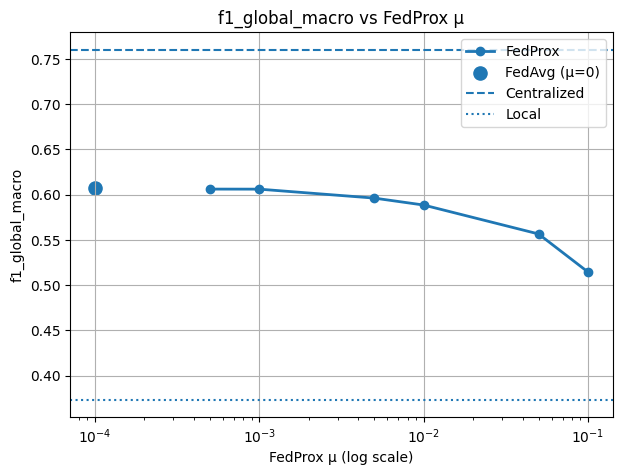

In [29]:
plot_mu_sweep(
    csv_path=csv_path_mu_2,
    metric="f1_global_macro"
)

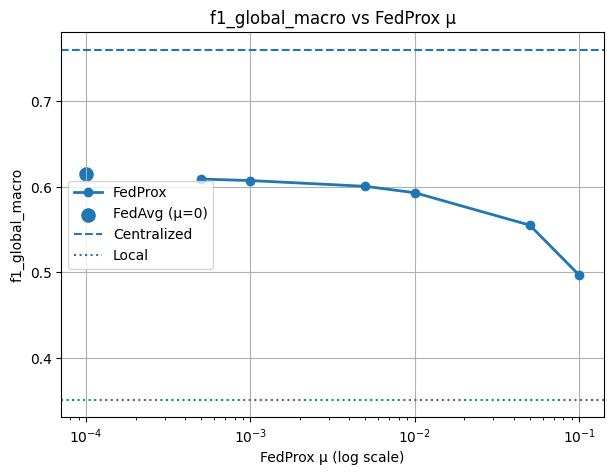

In [31]:
csv_path_mu_3 = r"C:\Users\Oskar\Desktop\fedprox_mu_sweep_summary_025_15.csv"
plot_mu_sweep(
    csv_path=csv_path_mu_3,
    metric="f1_global_macro"
)